# 20 -- N=128 gamma_* family: reconstructed spectra across gamma_* = 2..20

For each `gamma_* = 2, 3, ..., 20` (19 values), build `N_REALIZATIONS=16`
independent `N_b=128` simultaneous-nucleation realizations sized to that
target `gamma_*` (`box_size = R_*(gamma_*) * N_b^(1/3)`, following the same
`characteristic_scale`/`place_simultaneous_bubbles` convention already used
by `ptbuilder.weight_scan_diagnostics` and `08_chw_gamma_families.ipynb`),
compute each one's pairwise collision weights, and reconstruct its GW
spectrum from the `gs1-20` production scan (`19_production_scan.ipynb`) --
the only scan with enough `gamma_ij`/`kR_*` coverage for pair gammas up to
`pair_gamma_factor(2.5) * 20 = 50`. The plotted curve per `gamma_*` is the
pointwise median across its 16 realizations (single-realization curves
didn't converge as well as hoped -- see `n128_gamma_star_family.pdf`'s
earlier version).

`generate_surrogate` sizes every row's `omega_max` as `KR_MAX /
rstar_at_gamma(gamma_ij / pair_gamma_factor)` -- i.e. each row's raw `wlist`
was deliberately built so that, converted through the natural `R_*` of the
smallest target realization that would actually produce a pair at that
`gamma_ij`, it reaches exactly `kR_*=KR_MAX` at real computed data (and
`omega_min` carries headroom below `KR_MIN`). So for a `gamma_*` case here,
reconstructing directly onto a `k` grid spaced as
`geomspace(KR_MIN, KR_MAX, N_PLOT) / R_*(gamma_*)` lands exactly on that
built-in coverage -- no interpolation-driven extrapolation, no masking,
every curve spans `kR_* in [KR_MIN, KR_MAX]` exactly. All 16 realizations of
a given `gamma_*` share the same `R_*` (only the bubble placement seed
differs), so they're reconstructed onto the identical `k_plot` and combined
directly.

Weights run locally (`N_b=128` is small enough not to need SLURM) --
`19 * 16 = 304` jobs at ~35s each, so this section takes a while
(~35-40 min at this machine's core count).

In [1]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc, rcParams
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from scipy.interpolate import interp1d

import ptbuilder as pt
from ptbuilder.analysis import load_scan, load_weights, write_weights_input
from ptbuilder.weight_scan_diagnostics import (
    characteristic_scale, load_kinematics, place_simultaneous_bubbles,
)

rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rcParams['text.usetex'] = True

ROOT = Path(pt.__file__).parent.parent
DATA = ROOT / 'data'
PLOTS_DIR = ROOT / 'notebooks' / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

LAMBDA_BAR = 0.84
GAMMA_STARS = np.arange(2, 21)   # 2, 3, ..., 20
N_B = 128
N_REALIZATIONS = 16              # independent realizations per gamma_*, median-combined
N_T = 1024                       # weights time resolution per case
MAX_T_OVER_RSTAR = 2.5           # weights time window, in units of that case's own R_*
BASE_SEED = 128020

NEW_SCAN_DIR = DATA / 'runtime_scan_lb0.84_gs1-20_kR1-100_nw32'
NEW_SCAN_KR_MIN, NEW_SCAN_KR_MAX = 1.0, 100.0   # KR_MIN/KR_MAX from 19_production_scan.ipynb

N_PLOT = 200   # points per reconstructed curve
X_PLOT = np.geomspace(NEW_SCAN_KR_MIN, NEW_SCAN_KR_MAX, N_PLOT)   # shared kR_* axis -- same for every case

lb_tag = f'{LAMBDA_BAR:g}'.replace('.', 'p')
CASE_ROOT = DATA / f'gamma_star_weights_lb{lb_tag}_N{N_B}_ens{N_REALIZATIONS}'

## 1. Build the 19 x 16 N=128 realizations and run weights locally

`ptbuilder.weight_scan_diagnostics.run_grid`/`prepare_case` only build one
realization per `gamma_*` (the seed and output directory don't take a
realization index), so this builds the ensemble directly here, reusing
their lower-level pieces (`characteristic_scale`, `place_simultaneous_bubbles`,
`load_kinematics`) instead. Layout:
`data/gamma_star_weights_lb0p84_N128_ens16/gamma_star_{NNN}/realization_{RR}/`.
Already-written cases are skipped, so a rerun only fills in anything
missing.

In [2]:
import os
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed

kin = load_kinematics(DATA / f'phi4_lambda_bar{LAMBDA_BAR:g}/instanton.h5')

cases = []
for gamma_star in GAMMA_STARS:
    _, R_star = characteristic_scale(kin, float(gamma_star))
    box_size = R_star * N_B ** (1.0 / 3.0)
    for realization in range(N_REALIZATIONS):
        case_dir = CASE_ROOT / f'gamma_star_{int(gamma_star):03d}' / f'realization_{realization:02d}'
        inp = case_dir / 'weights_input.h5'
        out = case_dir / 'weights_output.h5'
        if not inp.exists():
            case_dir.mkdir(parents=True, exist_ok=True)
            seed = int(BASE_SEED + gamma_star * 1_000_003 + N_B + realization * 100_000_003)
            positions = place_simultaneous_bubbles(
                N_B, box_size, seed, min_separation=2.0 * kin.profile.rmid_0)
            times = np.linspace(0.0, MAX_T_OVER_RSTAR * R_star, N_T)
            write_weights_input(inp, positions, times, kin, box_size, collision_radius='mid')
            with h5py.File(inp, 'a') as f:
                f.attrs['gamma_star'] = float(gamma_star)
                f.attrs['R_star'] = R_star
                f.attrs['placement_seed'] = seed
                f.attrs['realization'] = realization
        cases.append((inp, out))

binary = ROOT / 'cpp/weights/weights'
env = os.environ.copy()
env['OMP_NUM_THREADS'] = '2'


def run_one(paths):
    inp, out = paths
    if not out.exists():
        subprocess.run([str(binary), str(inp), str(out)], check=True,
                       env=env, stdout=subprocess.DEVNULL)
    return out


with ThreadPoolExecutor(max_workers=5) as pool:
    futures = [pool.submit(run_one, paths) for paths in cases]
    for i, future in enumerate(as_completed(futures), 1):
        res = future.result()
        print(f'[{i:03d}/{len(futures)}] {res.parent.parent.name}/{res.parent.name}', flush=True)

[001/304] gamma_star_002/realization_03


[002/304] gamma_star_002/realization_02


[003/304] gamma_star_002/realization_05


[004/304] gamma_star_002/realization_01


[005/304] gamma_star_002/realization_06


...

[300/304] gamma_star_020/realization_15


[301/304] gamma_star_020/realization_05


[302/304] gamma_star_020/realization_09


[303/304] gamma_star_020/realization_13


[304/304] gamma_star_020/realization_04


## 2. Load the gs1-20 production scan

Self-contained, non-rectangular scan -- each `gamma_ij` row has its own
`times`/`wlist`, so there's no shared `(gamma_ij, t)` grid to hand directly
to a grid interpolator. `build_scan_interp(k_out)` removes both sources of
non-rectangularity up front: every row is resampled onto the same `k_out`
(as before) *and* onto the same `t_common` grid (new -- matching the
scan's own finest native time resolution), producing one rectangular
`(gamma_ij, t_common, k)` cube. A single `scipy.interpolate.
RegularGridInterpolator` over that cube then answers every `(gamma_ij, t)`
query in one vectorized call, reproducing the same bilinear-in-log-space
interpolation the old per-row/per-query `interp1d` + manual gamma-bracket
lookup did -- just computed once per `gamma_*` instead of once per pair.
That per-pair Python/`interp1d` call overhead (~600K calls across the
ensemble) was the actual bottleneck, not the weights binary.

In [3]:
from scipy.interpolate import RegularGridInterpolator

scan = load_scan(NEW_SCAN_DIR)
scan_gammas = np.array([r.gamma_ij for r in scan.rows])
scan_t_bounds = np.array([min(r.times[0] for r in scan.rows), scan.t_max])

# t_common: shared time grid every row gets resampled onto. Sized to the
# longest-running row's own point count (a row's own resolution is already
# fixed by generate_surrogate's dt -- this doesn't add resolution, it just
# gives every row a common axis to sit on without losing any).
N_T_COMMON = max(len(r.times) for r in scan.rows)
t_common = np.linspace(0.0, scan.t_max, N_T_COMMON)


def build_scan_interp(k_out):
    """(gamma_ij, t) -> spectrum interpolator projected onto k_out, backed by
    a single rectangular (gamma_ij, t_common, k_out) cube."""
    Nk = len(k_out)

    spec_on_kout = []
    for r in scan.rows:
        spec_k = np.zeros((len(r.times), Nk))
        for it in range(len(r.times)):
            spec_k[it] = np.interp(k_out, r.wlist, r.spectrum[it], left=0., right=0.)
        spec_on_kout.append(spec_k)

    floor = max(s.max() for s in spec_on_kout) * 1e-12
    log_floor = np.log(floor)

    cube = np.empty((len(scan.rows), N_T_COMMON, Nk))
    for ir, (r, spec_k) in enumerate(zip(scan.rows, spec_on_kout)):
        log_spec = np.log(np.maximum(spec_k, floor))
        f = interp1d(r.times, log_spec, axis=0, kind='linear', bounds_error=False,
                     fill_value=(log_floor, log_spec[-1]))
        cube[ir] = f(t_common)

    rgi = RegularGridInterpolator((scan_gammas, t_common), cube,
                                  bounds_error=False, fill_value=log_floor)

    def interp_fn(pts):
        g_clip = np.clip(pts[:, 0], scan_gammas.min(), scan_gammas.max())
        query = np.column_stack([g_clip, pts[:, 1]])
        return np.exp(rgi(query))

    return interp_fn

Loaded scan runtime_scan_lb0.84_gs1-20_kR1-100_nw32: 124 rows, gamma_ij in [1.000, 50.000], T_MAX=416.102


## 3. Reconstruct each realization's spectrum, then the median per gamma_*

The real bottleneck turned out to be neither per-call overhead nor the
interpolation method (both a `RegularGridInterpolator` cube and a manual
vectorized gather were tested and came out no faster than the original,
~7s per realization) -- it's that every collision weight is nonzero for
only ~11-13% of the 1024 time steps, and *always* as a single contiguous
block (verified against real weights data: 997/997 pairs in a test case had
zero gaps in their nonzero region). The original code queried the
interpolator over the full clipped time range regardless, computing `exp()`
over ~90% pure zero-weighted padding for no reason. `bm_reconstruct` now
slices each pair down to its own nonzero window (+1 point for the trailing
diff) before querying -- since the skipped points are multiplied by exactly
zero anyway, this changes nothing mathematically (verified bit-for-bit
identical against the untrimmed version across every pair in three test
cases) and cut one realization's query-point count from ~1M to ~130K
(~25x faster in isolation). Timed explicitly below to compare against the
untrimmed ~20 minute run.

In [4]:
import time


def bm_reconstruct(gamma, weights_t, weights_times, t_max, interp_fn, times, gammas, Nk):
    """Same math as a full-range reconstruction, but only queries interp_fn
    over this pair's own contiguous nonzero-weight window (+1 trailing point
    for the diff) -- every skipped point is multiplied by exactly zero
    weight, so this is exact, not an approximation (verified against the
    untrimmed version, see markdown above)."""
    g = float(np.clip(gamma, gammas.min(), gammas.max()))
    t_hi = min(t_max, times[-1])

    nz = np.where(weights_t > 0)[0]
    if len(nz) == 0:
        return np.zeros(Nk)
    lo, hi = nz[0], min(nz[-1] + 2, len(weights_times))
    t_window = weights_times[lo:hi]
    w_window = weights_t[lo:hi]

    mask = (t_window >= times[0]) & (t_window <= t_hi)
    t_comp = t_window[mask]
    w_comp = w_window[mask]
    if len(t_comp) == 0 or t_comp[-1] < t_hi:
        t_comp = np.append(t_comp, t_hi)
        w_comp = np.append(w_comp, np.interp(t_hi, weights_times, weights_t))
    if len(t_comp) < 2:
        return np.zeros(Nk)

    pts = np.column_stack([np.full(len(t_comp), g), t_comp])
    specs = interp_fn(pts)
    delta = np.diff(specs, axis=0)
    return (w_comp[:len(t_comp) - 1, None] * delta).sum(axis=0)


t_start = time.time()

ensembles = {}
reconstructions_median = {}
case_meta = {}
for gamma_star in GAMMA_STARS:
    gdir = CASE_ROOT / f'gamma_star_{int(gamma_star):03d}'
    with h5py.File(gdir / 'realization_00' / 'weights_input.h5', 'r') as f:
        R_star = float(f.attrs['R_star'])

    k_plot = X_PLOT / R_star   # exactly kR_* = X_PLOT once multiplied back by R_star
    interp_fn = build_scan_interp(k_plot)

    spectra = np.zeros((N_REALIZATIONS, N_PLOT))
    n_pairs_list = []
    L_box = None
    for realization in range(N_REALIZATIONS):
        rdir = gdir / f'realization_{realization:02d}'
        with h5py.File(rdir / 'weights_input.h5', 'r') as f:
            L_box = float(f.attrs['L'])
            weights_times = f['t'][:]
        weights, pair_i, pair_j, pair_gammas = load_weights(rdir / 'weights_output.h5', N_T)

        spectrum = np.zeros(N_PLOT)
        for w_row, g in zip(weights, pair_gammas):
            spectrum += bm_reconstruct(float(g), w_row, weights_times, weights_times[-1],
                                       interp_fn, scan_t_bounds, scan_gammas, N_PLOT)
        spectra[realization] = spectrum
        n_pairs_list.append(len(pair_i))

    ensembles[float(gamma_star)] = spectra
    reconstructions_median[float(gamma_star)] = np.median(spectra, axis=0)
    case_meta[float(gamma_star)] = dict(R_star=R_star, L_box=L_box)
    print(f'gamma_*={gamma_star:2d}: R_*={R_star:.4f}, L={L_box:.2f}, '
          f'{N_REALIZATIONS} realizations, pairs {min(n_pairs_list)}-{max(n_pairs_list)}')

print(f'\nSection 3 wall time: {time.time() - t_start:.1f}s (untrimmed version took ~20 min)')

gamma_*= 2: R_*=27.7024, L=139.61, 16 realizations, pairs 974-1011


gamma_*= 3: R_*=41.5806, L=209.55, 16 realizations, pairs 970-1015


gamma_*= 4: R_*=55.4573, L=279.49, 16 realizations, pairs 983-1009


gamma_*= 5: R_*=69.3319, L=349.41, 16 realizations, pairs 986-1007


gamma_*= 6: R_*=83.2054, L=419.33, 16 realizations, pairs 964-1010


...

gamma_*=16: R_*=221.9190, L=1118.40, 16 realizations, pairs 970-1013


gamma_*=17: R_*=235.7897, L=1188.31, 16 realizations, pairs 973-1002


gamma_*=18: R_*=249.6603, L=1258.21, 16 realizations, pairs 980-1009


gamma_*=19: R_*=263.5310, L=1328.11, 16 realizations, pairs 979-1011


gamma_*=20: R_*=277.4016, L=1398.02, 16 realizations, pairs 969-1009

Section 3 wall time: 88.0s (untrimmed version took ~20 min)


## 4. Convert to CHW units and plot the gamma_* family (median of 16)

Each curve's median spectrum was reconstructed directly on `k_plot = X_PLOT
/ R_star` (its own realization's `R_*`), so `energy_to_chw`'s `x` output is
`X_PLOT` again for every case, exactly -- no masking needed. Curves are
colored by `gamma_*` with a colorbar, matching the style already used in
`ptbuilder.weight_scan_diagnostics.plot_diagnostics`.

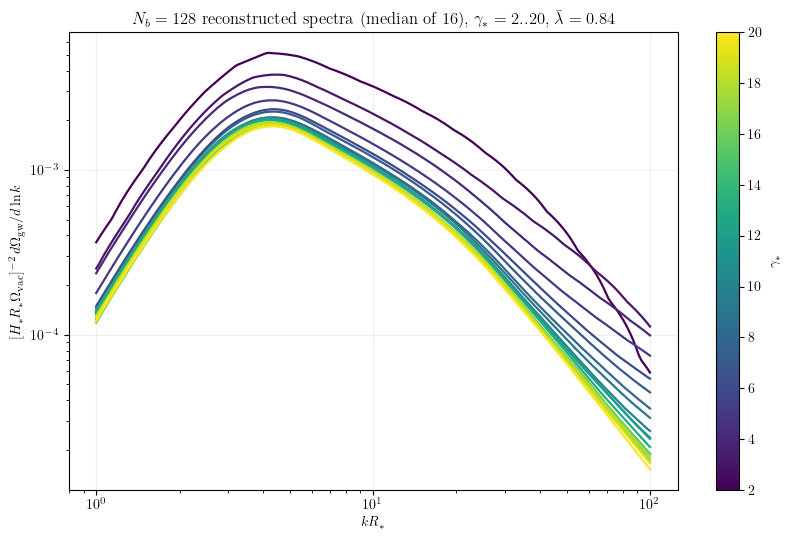

In [5]:
def rho_vac_bar(lambda_bar):
    """False-minus-true vacuum energy in BM dimensionless units."""
    U = 3.0 + np.sqrt(9.0 - 8.0 * lambda_bar)
    V_true = 0.5 - U / (4.0 * lambda_bar) + U**2 / (32.0 * lambda_bar)
    return -V_true


def energy_to_chw(k, dE_dlnk, Rstar, lambda_bar, volume):
    rho_vac = rho_vac_bar(lambda_bar)
    x = np.asarray(k) * Rstar
    y = (3.0 / (8.0 * np.pi * rho_vac**2 * Rstar**2 * volume)) * np.asarray(dE_dlnk)
    return x, y


norm = Normalize(vmin=GAMMA_STARS.min(), vmax=GAMMA_STARS.max())
cmap = plt.get_cmap('viridis')

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for gamma_star in GAMMA_STARS:
    meta = case_meta[float(gamma_star)]
    k_plot = X_PLOT / meta['R_star']
    x, y = energy_to_chw(k_plot, reconstructions_median[float(gamma_star)],
                         meta['R_star'], LAMBDA_BAR, meta['L_box']**3)
    ax.plot(x, y, color=cmap(norm(gamma_star)), lw=1.6)

colorbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax)
colorbar.set_label(r'$\gamma_*$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$kR_*$')
ax.set_ylabel(r'$[H_*R_*\Omega_{\rm vac}]^{-2}\,d\Omega_{\rm gw}/d\ln k$')
ax.set_title(rf'$N_b={N_B}$ reconstructed spectra (median of {N_REALIZATIONS}), '
            rf'$\gamma_*={GAMMA_STARS[0]}..{GAMMA_STARS[-1]}$, $\bar{{\lambda}}={LAMBDA_BAR}$')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'n128_gamma_star_family.pdf', bbox_inches='tight')
plt.show()

## 5. Peak amplitude vs gamma_*

Peak of the median-of-16 curve at each `gamma_*`, plus the spread of the 16
individual realizations' own peaks (shaded band = min-max), to see whether
the peak amplitude is converging to something as `gamma_*` grows.

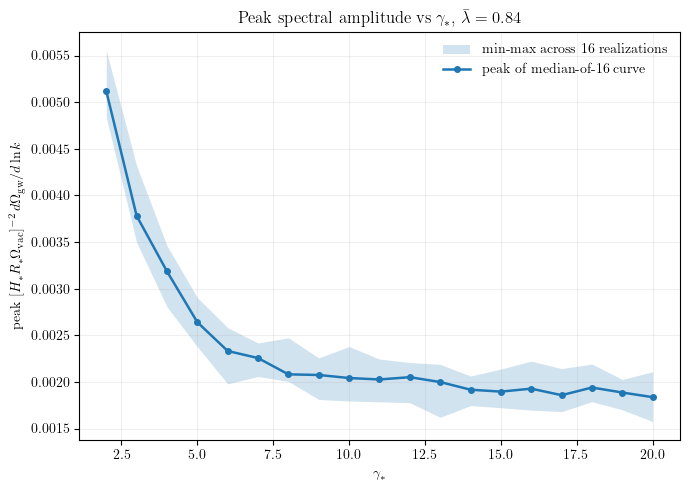

In [6]:
peak_median = np.zeros(len(GAMMA_STARS))
peak_min = np.zeros(len(GAMMA_STARS))
peak_max = np.zeros(len(GAMMA_STARS))

for ig, gamma_star in enumerate(GAMMA_STARS):
    meta = case_meta[float(gamma_star)]
    k_plot = X_PLOT / meta['R_star']

    _, y_median = energy_to_chw(k_plot, reconstructions_median[float(gamma_star)],
                                meta['R_star'], LAMBDA_BAR, meta['L_box']**3)
    peak_median[ig] = y_median.max()

    peaks_per_realization = np.array([
        energy_to_chw(k_plot, spec, meta['R_star'], LAMBDA_BAR, meta['L_box']**3)[1].max()
        for spec in ensembles[float(gamma_star)]
    ])
    peak_min[ig] = peaks_per_realization.min()
    peak_max[ig] = peaks_per_realization.max()

fig, ax = plt.subplots(figsize=(7, 5))
ax.fill_between(GAMMA_STARS, peak_min, peak_max, color='C0', alpha=0.2, linewidth=0,
                label='min-max across 16 realizations')
ax.plot(GAMMA_STARS, peak_median, 'o-', color='C0', lw=1.8, ms=4,
        label='peak of median-of-16 curve')
ax.set_xlabel(r'$\gamma_*$')
ax.set_ylabel(r'peak $[H_*R_*\Omega_{\rm vac}]^{-2}\,d\Omega_{\rm gw}/d\ln k$')
ax.set_title(rf'Peak spectral amplitude vs $\gamma_*$, $\bar{{\lambda}}={LAMBDA_BAR}$')
ax.grid(alpha=0.2)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'n128_gamma_star_peak_convergence.pdf', bbox_inches='tight')
plt.show()

## 6. Pair-level diagnostics: gamma_ij distribution and last collision times

Same two diagnostics as `ptbuilder.weight_scan_diagnostics.plot_diagnostics`
(pair-`gamma_ij` histogram vs target `gamma_*`, and last-nonzero-weight-time
vs pair `gamma_ij`), rebuilt here directly from the already-computed
`weights_output.h5` files rather than calling that function -- its
`collect_grid` expects one realization per `gamma_*`
(`gamma_star_XXX/weights_output.h5`), not this notebook's ensemble layout
(`gamma_star_XXX/realization_RR/weights_output.h5`). Pooling all 16
realizations per `gamma_*` (instead of `plot_diagnostics`'s single
realization) gives substantially more statistics per point.

In [7]:
all_pair_gamma = {}          # gamma_star -> pair gamma_ij, pooled over 16 realizations
all_pair_last_time = {}      # gamma_star -> last nonzero-weight time per pair (NaN if none)
all_pair_integrated_w = {}   # gamma_star -> integrated weight per pair

for gamma_star in GAMMA_STARS:
    gdir = CASE_ROOT / f'gamma_star_{int(gamma_star):03d}'
    gammas_list, last_time_list, integ_w_list = [], [], []
    for realization in range(N_REALIZATIONS):
        rdir = gdir / f'realization_{realization:02d}'
        with h5py.File(rdir / 'weights_input.h5', 'r') as f:
            weights_times = f['t'][:]
        weights, pair_i, pair_j, pair_gammas = load_weights(rdir / 'weights_output.h5', N_T)

        nonzero = weights > 0.0
        has_nonzero = nonzero.any(axis=1)
        last_idx = len(weights_times) - 1 - np.argmax(nonzero[:, ::-1], axis=1)
        last_time = np.where(has_nonzero, weights_times[last_idx], np.nan)

        gammas_list.append(pair_gammas)
        last_time_list.append(last_time)
        integ_w_list.append(np.trapz(weights, weights_times, axis=1))

    all_pair_gamma[gamma_star] = np.concatenate(gammas_list)
    all_pair_last_time[gamma_star] = np.concatenate(last_time_list)
    all_pair_integrated_w[gamma_star] = np.concatenate(integ_w_list)

print(f'Loaded pair-level gamma_ij / last-nonzero-time for {len(GAMMA_STARS)} gamma_* cases '
      f'({N_REALIZATIONS} realizations each)')

Loaded pair-level gamma_ij / last-nonzero-time for 19 gamma_* cases (16 realizations each)


### 6a. Weighted distributions vs target gamma_*: gamma_ij/gamma_* and last collision time / R_*

Both panels are integrated-weight-fraction 2D histograms (same style,
`Greys`/`LogNorm`), sharing the `gamma_*` x-axis. Top: pair `gamma_ij`
normalized by the target `gamma_*` -- this is the ratio the production
scan's own `pair_gamma_factor=2.5` design assumption is about, and
normalizing by `gamma_*` turns the raw-`gamma_ij` version's triangular
shape rectangular, same as the (already `gamma_*`-normalized) time panel.
Bottom: last nonzero-weight time normalized by that `gamma_*`'s own `R_*`.

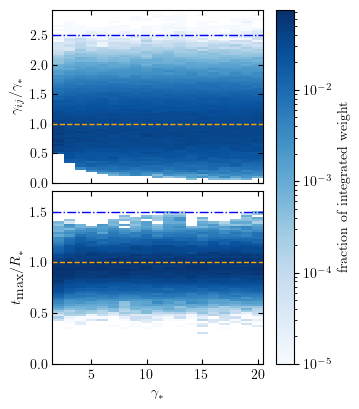

In [8]:
from matplotlib.colors import LogNorm

x_edges = np.arange(GAMMA_STARS.min() - 0.5, GAMMA_STARS.max() + 1.5)

# Panel 1: gamma_ij / gamma_* distribution
all_ratio_gamma = {gamma_star: all_pair_gamma[gamma_star] / gamma_star for gamma_star in GAMMA_STARS}
ratio_gamma_concat = np.concatenate(list(all_ratio_gamma.values()))
y_edges_gamma = np.linspace(0.0, ratio_gamma_concat.max() * 1.03, 81)

weighted_gamma = np.zeros((len(y_edges_gamma) - 1, len(GAMMA_STARS)))
for ix, gamma_star in enumerate(GAMMA_STARS):
    weighted_gamma[:, ix], _ = np.histogram(all_ratio_gamma[gamma_star], bins=y_edges_gamma,
                                            weights=all_pair_integrated_w[gamma_star])
    if weighted_gamma[:, ix].sum() > 0:
        weighted_gamma[:, ix] /= weighted_gamma[:, ix].sum()

# Panel 2: last collision time / R_* distribution
all_ratio_time = {gamma_star: all_pair_last_time[gamma_star] / case_meta[float(gamma_star)]['R_star']
                  for gamma_star in GAMMA_STARS}
ratio_time_concat = np.concatenate([r[np.isfinite(r)] for r in all_ratio_time.values()])
y_edges_time = np.linspace(0.0, 1.7, 81)

weighted_time = np.zeros((len(y_edges_time) - 1, len(GAMMA_STARS)))
for ix, gamma_star in enumerate(GAMMA_STARS):
    ratio = all_ratio_time[gamma_star]
    valid = np.isfinite(ratio)
    weighted_time[:, ix], _ = np.histogram(ratio[valid], bins=y_edges_time,
                                           weights=all_pair_integrated_w[gamma_star][valid])
    if weighted_time[:, ix].sum() > 0:
        weighted_time[:, ix] /= weighted_time[:, ix].sum()

# Single shared color scale for both panels, since they'll share one colorbar.
vmin = 1e-5
vmax = max(weighted_gamma[weighted_gamma > 0].max(), weighted_time[weighted_time > 0].max())
norm = LogNorm(vmin=vmin, vmax=vmax)

FS = 10  # single-column figure -- keep text legible at this size




fig, axes = plt.subplots(2, 1, figsize=(3.4, 4.6), sharex=True)
fig.subplots_adjust(hspace=0.05)

cmap = 'Blues'

pcm0 = axes[0].pcolormesh(x_edges, y_edges_gamma, weighted_gamma, shading='auto',
                          norm=norm, cmap=cmap)
axes[0].axhline(1.0, color='orange', ls='--', lw=1.0, label=r'$\gamma_{ij}=\gamma_*$')
axes[0].axhline(2.5, color='blue', ls='-.', lw=1.0, label=r'$\gamma_{ij}=2.5\gamma_*$')
axes[0].set_ylabel(r'$\gamma_{ij} / \gamma_*$', fontsize=FS)
#axes[0].legend(frameon=False, fontsize=FS - 1)
axes[0].tick_params(axis='both', labelsize=FS, labelbottom=False, top=True, right=True, direction='in')

pcm1 = axes[1].pcolormesh(x_edges, y_edges_time, weighted_time, shading='auto',
                          norm=norm, cmap=cmap)
axes[1].set_ylabel(r'$t_\textrm{max} / R_*$', fontsize=FS)
axes[1].set_xlabel(r'$\gamma_*$', fontsize=FS)
axes[1].tick_params(axis='both', labelsize=FS, top=True, right=True, direction='in')
axes[1].axhline(1.0, color='orange', ls='--', lw=1.0, label=r'$\gamma_{ij}=\gamma_*$')
axes[1].axhline(1.5, color='blue', ls='-.', lw=1.0, label=r'$\gamma_{ij}=2.5\gamma_*$')

colorbar = fig.colorbar(pcm1, ax=list(axes), label='fraction of integrated weight')
colorbar.ax.tick_params(labelsize=FS)
colorbar.set_label('fraction of integrated weight', fontsize=FS)

fig.savefig(PLOTS_DIR / 'gamma_star_distribution.pdf', bbox_inches='tight')
plt.show()

## 7. Combined single-column figure

Same combined-figure layout as `23_n_b_family_gamma20.ipynb`'s Section 6
(spectra family on top, peak convergence below, one shared colorbar) --
here colored by `gamma_*` instead of `N_b`, using the same calm single-hue
colormap instead of `viridis`.

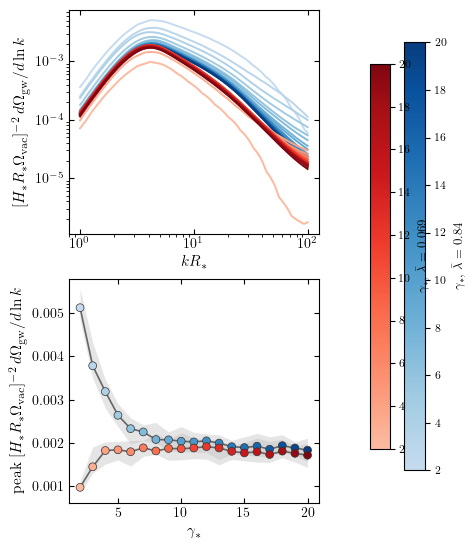

In [9]:
import pickle
import matplotlib.colors as mcolors


def truncate_colormap(cmap, minval=0.25, maxval=0.95, n=256):
    """A single-hue sequential colormap (e.g. 'Blues') run through its full
    range includes near-white at the low end -- truncating it keeps every
    curve visible while staying a calm, single-hue gradient rather than
    viridis's full-spectrum look."""
    return mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n)))


# lambda_bar=0.069 gamma_*-family (same N_b=128, same gamma_* grid, its own
# gs1-20 scan), built by an identical standalone script -- overlaid here
# (in Reds) on the same axes as the lambda_bar=0.84 family (Blues) above,
# so the two families' peak amplitudes can be compared directly.
with open(DATA / 'gamma_star_weights_lb0p069_N128_ens16_reconstructed.pkl', 'rb') as f:
    d069 = pickle.load(f)
GAMMA_STARS_069 = d069['GAMMA_STARS']
X_PLOT_069 = d069['X_PLOT']
LAMBDA_BAR_069 = d069['LAMBDA_BAR']
ensembles_069 = d069['ensembles']
reconstructions_median_069 = d069['reconstructions_median']
case_meta_069 = d069['case_meta']

peak_median_069 = np.zeros(len(GAMMA_STARS_069))
peak_min_069 = np.zeros(len(GAMMA_STARS_069))
peak_max_069 = np.zeros(len(GAMMA_STARS_069))
for ig, gamma_star in enumerate(GAMMA_STARS_069):
    meta = case_meta_069[float(gamma_star)]
    k_plot = X_PLOT_069 / meta['R_star']
    _, y_median = energy_to_chw(k_plot, reconstructions_median_069[float(gamma_star)],
                                meta['R_star'], LAMBDA_BAR_069, meta['L_box']**3)
    peak_median_069[ig] = y_median.max()
    peaks_per_realization = np.array([
        energy_to_chw(k_plot, spec, meta['R_star'], LAMBDA_BAR_069, meta['L_box']**3)[1].max()
        for spec in ensembles_069[float(gamma_star)]
    ])
    peak_min_069[ig] = peaks_per_realization.min()
    peak_max_069[ig] = peaks_per_realization.max()


norm = Normalize(vmin=GAMMA_STARS.min(), vmax=GAMMA_STARS.max())
norm_069 = Normalize(vmin=GAMMA_STARS_069.min(), vmax=GAMMA_STARS_069.max())
cmap = truncate_colormap(plt.get_cmap('Blues'))
cmap_069 = truncate_colormap(plt.get_cmap('Reds'))

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(4.6, 6.4))

# --- Top: spectra family -----------------------------------------------
for gamma_star in GAMMA_STARS:
    meta = case_meta[float(gamma_star)]
    k_plot = X_PLOT / meta['R_star']
    x, y = energy_to_chw(k_plot, reconstructions_median[float(gamma_star)],
                         meta['R_star'], LAMBDA_BAR, meta['L_box']**3)
    ax_top.plot(x, y, color=cmap(norm(gamma_star)), lw=1.4)

for gamma_star in GAMMA_STARS_069:
    meta = case_meta_069[float(gamma_star)]
    k_plot = X_PLOT_069 / meta['R_star']
    x, y = energy_to_chw(k_plot, reconstructions_median_069[float(gamma_star)],
                         meta['R_star'], LAMBDA_BAR_069, meta['L_box']**3)
    ax_top.plot(x, y, color=cmap_069(norm_069(gamma_star)), lw=1.4)

ax_top.set_xscale('log')
ax_top.set_yscale('log')
ax_top.set_xlabel(r'$kR_*$', fontsize=11)
ax_top.set_ylabel(r'$[H_*R_*\Omega_{\rm vac}]^{-2}\,d\Omega_{\rm gw}/d\ln k$', fontsize=11)
ax_top.tick_params(axis='both', labelsize=10, top=True, right=True, direction='in')

# --- Bottom: peak convergence, colored the same way as the spectra -----
ax_bot.fill_between(GAMMA_STARS, peak_min, peak_max, color='0.75', alpha=0.4, linewidth=0)
ax_bot.plot(GAMMA_STARS, peak_median, '-', color='0.4', lw=1.2, zorder=2)
ax_bot.scatter(GAMMA_STARS, peak_median, c=GAMMA_STARS, cmap=cmap, norm=norm,
              s=32, zorder=3, edgecolor='0.2', linewidth=0.5)

ax_bot.fill_between(GAMMA_STARS_069, peak_min_069, peak_max_069, color='0.75', alpha=0.4, linewidth=0)
ax_bot.plot(GAMMA_STARS_069, peak_median_069, '-', color='0.4', lw=1.2, zorder=2)
ax_bot.scatter(GAMMA_STARS_069, peak_median_069, c=GAMMA_STARS_069, cmap=cmap_069, norm=norm_069,
              s=32, zorder=3, edgecolor='0.2', linewidth=0.5)

ax_bot.set_xlabel(r'$\gamma_*$', fontsize=11)
ax_bot.set_ylabel(r'peak $[H_*R_*\Omega_{\rm vac}]^{-2}\,d\Omega_{\rm gw}/d\ln k$', fontsize=11)
ax_bot.tick_params(axis='both', labelsize=10, top=True, right=True, direction='in')

cb1 = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=[ax_top, ax_bot],
                   fraction=0.06, pad=0.04)
cb1.set_label(r'$\gamma_*$, $\bar\lambda=0.84$', fontsize=9)
cb1.ax.tick_params(labelsize=8)

cb2 = fig.colorbar(ScalarMappable(norm=norm_069, cmap=cmap_069), ax=[ax_top, ax_bot],
                   fraction=0.06, pad=0.16)
cb2.set_label(r'$\gamma_*$, $\bar\lambda=0.069$', fontsize=9)
cb2.ax.tick_params(labelsize=8)

fig.savefig(PLOTS_DIR / 'n128_gamma_star_family_combined.pdf', bbox_inches='tight')
plt.show()